In [ ]:
import requests
import pandas as pd
from datetime import datetime, timezone
from dune_client.client import DuneClient
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import ttest_ind

In [ ]:
BASE = "https://api.binance.com"
SYMBOL = "ETHUSDT"
INTERVAL = "1d"

DUNE_API_KEY = "xxxxxxxx"  # replace with your Dune API key

### Pull Binance ETHUSDT daily volume

In [ ]:
def to_ms(date_str):
    dt = datetime.strptime(date_str, "%Y-%m-%d").replace(tzinfo=timezone.utc)
    return int(dt.timestamp() * 1000)

def fetch_klines(symbol, interval, start_ms, end_ms, limit=1000):
    url = f"{BASE}/api/v3/klines"
    params = {
        "symbol": symbol,
        "interval": interval,
        "startTime": start_ms,
        "endTime": end_ms,
        "limit": limit
    }
    r = requests.get(url, params=params, timeout=30)
    r.raise_for_status()
    return r.json()

In [14]:
start = to_ms("2025-09-01")
end   = to_ms("2026-03-01")

data = fetch_klines(SYMBOL, INTERVAL, start, end)

# Binance kline array format includes:
# [ openTime, open, high, low, close, volume, closeTime,
#   quoteAssetVolume, numberOfTrades, takerBuyBaseVolume, takerBuyQuoteVolume, ignore ]
rows = []
for k in data:
    rows.append({
        "day": pd.to_datetime(k[0], unit="ms", utc=True).date(),
        "binance_eth_volume_usd": float(k[7])  # quoteAssetVolume in USDT ~ USD
    })

binance_df = pd.DataFrame(rows)
binance_df["day"] = pd.to_datetime(binance_df["day"])
binance_df.head()

,day,binance_eth_volume_usd
0,2025-09-01,2.244611e+09
1,2025-09-02,2.275753e+09
2,2025-09-03,2.146232e+09
3,2025-09-04,2.061920e+09
4,2025-09-05,2.722931e+09


### Pulling ETH Volume From Dune

In [7]:
dune = DuneClient(DUNE_API_KEY)

In [19]:
query_result = dune.get_latest_result(6774633)
print(query_result)

rows = query_result.result.rows
eth_volume_df = pd.DataFrame(rows)

eth_volume_df.head()

# eth_volume_df.to_csv('../data/eth_volume.csv', index=False)

ResultsResponse(execution_id='01KJVC7QVJG7QW8H50K3PW8DH8', query_id=6774633, state=<ExecutionState.COMPLETED: 'QUERY_STATE_COMPLETED'>, times=TimeData(submitted_at=datetime.datetime(2026, 3, 4, 2, 53, 35, 987206, tzinfo=tzutc()), execution_started_at=datetime.datetime(2026, 3, 4, 2, 53, 37, 474021, tzinfo=tzutc()), execution_ended_at=datetime.datetime(2026, 3, 4, 2, 53, 40, 986032, tzinfo=tzutc()), expires_at=datetime.datetime(2026, 6, 2, 2, 53, 40, 986044, tzinfo=tzutc()), cancelled_at=None), result=ExecutionResult(rows=[{'day': '2025-09-01 00:00:00.000 UTC', 'uniswap_eth_volume_usd': 723366275.5509459}, {'day': '2025-09-02 00:00:00.000 UTC', 'uniswap_eth_volume_usd': 738466329.7501161}, {'day': '2025-09-03 00:00:00.000 UTC', 'uniswap_eth_volume_usd': 618580038.4613243}, {'day': '2025-09-04 00:00:00.000 UTC', 'uniswap_eth_volume_usd': 619377458.2863755}, {'day': '2025-09-05 00:00:00.000 UTC', 'uniswap_eth_volume_usd': 754094056.5484596}, {'day': '2025-09-06 00:00:00.000 UTC', 'uniswap

,day,uniswap_eth_volume_usd
0,2025-09-01 00:00:00.000 UTC,7.233663e+08
1,2025-09-02 00:00:00.000 UTC,7.384663e+08
2,2025-09-03 00:00:00.000 UTC,6.185800e+08
3,2025-09-04 00:00:00.000 UTC,6.193775e+08
4,2025-09-05 00:00:00.000 UTC,7.540941e+08


### Merge CEX + DEX + Volatility

In [20]:
vol_df = pd.read_csv("../data/eth_volatility.csv")
dex_df = pd.read_csv("../data/eth_volume.csv")

In [ ]:
dex_df["day"] = pd.to_datetime(dex_df["day"])
vol_df["day"] = pd.to_datetime(vol_df["day"])

binance_df["day"] = pd.to_datetime(binance_df["day"]).dt.tz_localize(None)
dex_df["day"] = pd.to_datetime(dex_df["day"]).dt.tz_localize(None)
vol_df["day"] = pd.to_datetime(vol_df["day"]).dt.tz_localize(None)

df = (binance_df
      .merge(dex_df, on="day", how="inner")
      .merge(vol_df[["day","abs_return"]], on="day", how="inner"))

df["total_eth_spot_usd"] = df["binance_eth_volume_usd"] + df["uniswap_eth_volume_usd"]
df["dex_share"] = df["uniswap_eth_volume_usd"] / df["total_eth_spot_usd"]

# high vol days (top 20% abs return)
thr = df["abs_return"].quantile(0.8)
df["high_vol_day"] = (df["abs_return"] >= thr).astype(int)

df.head()

,day,binance_eth_volume_usd,uniswap_eth_volume_usd,abs_return,total_eth_spot_usd,dex_share,high_vol_day
0,2025-09-01,2.244611e+09,7.233663e+08,NaN,2.967977e+09,0.243724,0
1,2025-09-02,2.275753e+09,7.384663e+08,0.008850,3.014219e+09,0.244994,0
2,2025-09-03,2.146232e+09,6.185800e+08,0.008777,2.764812e+09,0.223733,0
3,2025-09-04,2.061920e+09,6.193775e+08,0.008850,2.681298e+09,0.230999,0
4,2025-09-05,2.722931e+09,7.540941e+08,0.018018,3.477025e+09,0.216879,0


### Analysis

In [24]:
df.groupby("high_vol_day")[["dex_share","uniswap_eth_volume_usd","binance_eth_volume_usd"]].mean()

,dex_share,uniswap_eth_volume_usd,binance_eth_volume_usd
high_vol_day,,,
0,0.216323,4.056441e+08,1.546910e+09
1,0.230763,5.112114e+08,1.795266e+09


In [25]:
high = df[df["high_vol_day"]==1]["dex_share"]
low  = df[df["high_vol_day"]==0]["dex_share"]

ttest_ind(high, low, equal_var=False)

TtestResult(statistic=np.float64(1.2450312678104214), pvalue=np.float64(0.21933524586792916), df=np.float64(46.67355869472885))

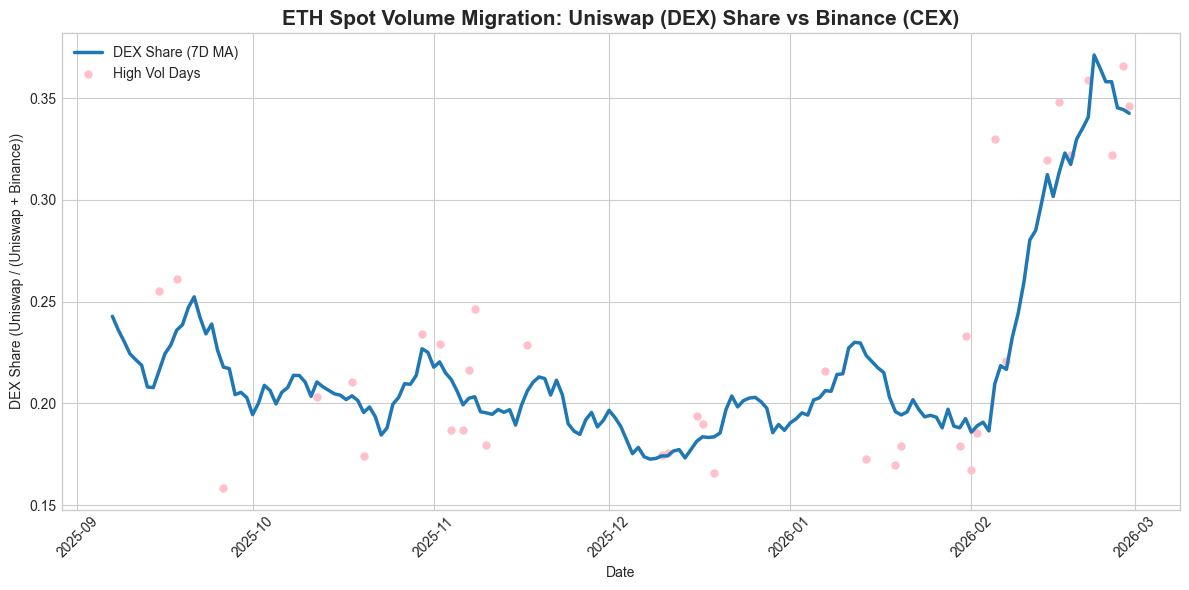

In [27]:
df["dex_share_7d"] = df["dex_share"].rolling(7).mean()

plt.style.use("seaborn-v0_8-whitegrid")
plt.figure(figsize=(12,6))

plt.plot(df["day"], df["dex_share_7d"], linewidth=2.5, label="DEX Share (7D MA)")

hv = df[df["high_vol_day"]==1]
plt.scatter(hv["day"], hv["dex_share"], s=25, label="High Vol Days", color='pink')

plt.title("ETH Spot Volume Migration: Uniswap (DEX) Share vs Binance (CEX)", fontsize=15, fontweight="bold")
plt.xlabel("Date")
plt.ylabel("DEX Share (Uniswap / (Uniswap + Binance))")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()